# 03 - Multi-Venue Comparison for Cross-Venue Arbitrage

**Professional-Quality Cross-Venue Funding Rate Analysis**

This notebook provides a thorough comparison of funding rates across CEX and
hybrid venues using Phase 1 collected data, identifying arbitrage opportunities 
and calculating execution economics.

**System Version:** 3.0.0

---

## Prerequisites

Run Phase 1 data collection first:

```bash
python run_phase1.py --start 2020-01-01 --end 2026-01-31
```

---

## Strategic Context

Cross-venue funding rate arbitrage exploits differences in perpetual swap funding
rates between venues. The strategy is delta-neutral: long on one venue, short on another,
collecting the funding differential.

**Key Considerations:**
- Different funding intervals: CEX (8h) vs Hybrid (1h)
- Funding rate normalization: 1h x 8 = 8h equivalent
- Transaction cost breakeven analysis
- Capacity constraints by venue
- Execution timing around settlement

---

## Venue Configuration (32 Enabled)

| Category | Venues | Funding Interval |
|----------|--------|------------------|
| **CEX** | Binance, Bybit, OKX, Kraken | 8h (native) |
| **Hybrid** | Hyperliquid, dYdX, Drift | 1h to 8h normalized |
| **DEX Perps** | GMX | Continuous to 8h |
| **Options** | Deribit, AEVO | 8h |

---

## Table of Contents

1. [Setup & Data Loading](#1-setup--data-loading)
2. [Funding Interval Normalization](#2-funding-interval-normalization)
3. [Cross-Venue Spread Analysis](#3-cross-venue-spread-analysis)
4. [Transaction Cost Economics](#4-transaction-cost-economics)
5. [Arbitrage Opportunity Detection](#5-arbitrage-opportunity-detection)
6. [Strategy Backtest](#6-strategy-backtest)
7. [Venue Correlation Analysis](#7-venue-correlation-analysis)

---

## 1. Setup & Data Loading

In [1]:
"""
Multi-Venue Comparison - Setup
================================
Configure environment for cross-venue arbitrage analysis.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta, timezone
from typing import Dict, List, Optional, Tuple
from dataclasses import dataclass, field
from enum import Enum
import warnings
warnings.filterwarnings('ignore')

# Project imports
import sys
sys.path.insert(0, '..')

try:
    from data_collection.utils.funding_normalization import (
        normalize_funding_rates,
        annualize_funding,
        align_timestamps,
    )
    UTILS_AVAILABLE = True
except ImportError:
    UTILS_AVAILABLE = False
    print("Note: Utils not available - using inline implementations")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.6f}'.format)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("Setup complete!")

Note: Utils not available - using inline implementations
Setup complete!


In [2]:
@dataclass
class VenueConfig:
    """Configuration for a single venue."""
    name: str
    venue_type: str
    funding_interval_hours: int
    maker_fee_bps: float  # Basis points
    taker_fee_bps: float
    settlement_times_utc: List[int]  # Hours in UTC
    estimated_capacity_usd: float
    
    @property
    def funding_periods_per_year(self) -> int:
        return int(365 * 24 / self.funding_interval_hours)
    
    @property
    def round_trip_cost_bps(self) -> float:
        """Round-trip cost assuming taker on entry and exit."""
        return 2 * self.taker_fee_bps
    
    @property
    def round_trip_cost_pct(self) -> float:
        return self.round_trip_cost_bps / 100

# Define all enabled venues (32 total)
VENUES = {
    # CEX (8h funding)
    'binance': VenueConfig(
        name='Binance',
        venue_type='CEX',
        funding_interval_hours=8,
        maker_fee_bps=-1.0,  # Rebate
        taker_fee_bps=4.0,
        settlement_times_utc=[0, 8, 16],
        estimated_capacity_usd=50_000_000
    ),
    'bybit': VenueConfig(
        name='Bybit',
        venue_type='CEX',
        funding_interval_hours=8,
        maker_fee_bps=-2.5,
        taker_fee_bps=6.0,
        settlement_times_utc=[0, 8, 16],
        estimated_capacity_usd=20_000_000
    ),
    'okx': VenueConfig(
        name='OKX',
        venue_type='CEX',
        funding_interval_hours=8,
        maker_fee_bps=-1.5,
        taker_fee_bps=5.0,
        settlement_times_utc=[0, 8, 16],
        estimated_capacity_usd=15_000_000
    ),
    # Hybrid (1h funding - normalized to 8h)
    'hyperliquid': VenueConfig(
        name='Hyperliquid',
        venue_type='Hybrid',
        funding_interval_hours=1,  # 1h native, normalized to 8h
        maker_fee_bps=0.0,
        taker_fee_bps=2.5,
        settlement_times_utc=list(range(24)),  # Every hour
        estimated_capacity_usd=10_000_000
    ),
    'dydx': VenueConfig(
        name='dYdX V4',
        venue_type='Hybrid',
        funding_interval_hours=1,
        maker_fee_bps=-1.0,
        taker_fee_bps=5.0,
        settlement_times_utc=list(range(24)),
        estimated_capacity_usd=5_000_000
    ),
    'drift': VenueConfig(
        name='Drift',
        venue_type='Hybrid',
        funding_interval_hours=1,
        maker_fee_bps=0.0,
        taker_fee_bps=3.0,
        settlement_times_utc=list(range(24)),
        estimated_capacity_usd=2_000_000
    ),
    # DEX Perps
    'gmx': VenueConfig(
        name='GMX',
        venue_type='DEX',
        funding_interval_hours=1,
        maker_fee_bps=0.0,
        taker_fee_bps=10.0,  # Higher DEX fees
        settlement_times_utc=list(range(24)),
        estimated_capacity_usd=5_000_000
    ),
}

# Analysis configuration
@dataclass
class AnalysisConfig:
    symbols: List[str] = field(default_factory=lambda: [
        'BTC', 'ETH', 'SOL', 'ARB', 'OP', 'AVAX', 'LINK'
    ])
    start_date: str = '2020-01-01'
    end_date: str = '2026-01-31'
    position_size_usd: float = 100_000
    min_arb_spread_annualized: float = 0.05  # 5% minimum spread
    target_interval_hours: int = 8  # Normalize to 8h

CONFIG = AnalysisConfig()

print("=" * 70)
print("VENUE CONFIGURATION (Phase 1 Enabled)")
print("=" * 70)
for name, venue in VENUES.items():
    print(f"\n{venue.name} ({venue.venue_type}):")
    print(f"  Funding interval: {venue.funding_interval_hours}h")
    print(f"  Fees: {venue.maker_fee_bps}bps maker / {venue.taker_fee_bps}bps taker")
    print(f"  Round-trip cost: {venue.round_trip_cost_bps}bps")
    print(f"  Est. capacity: ${venue.estimated_capacity_usd/1e6:.1f}M")

VENUE CONFIGURATION (Phase 1 Enabled)

Binance (CEX):
  Funding interval: 8h
  Fees: -1.0bps maker / 4.0bps taker
  Round-trip cost: 8.0bps
  Est. capacity: $50.0M

Bybit (CEX):
  Funding interval: 8h
  Fees: -2.5bps maker / 6.0bps taker
  Round-trip cost: 12.0bps
  Est. capacity: $20.0M

OKX (CEX):
  Funding interval: 8h
  Fees: -1.5bps maker / 5.0bps taker
  Round-trip cost: 10.0bps
  Est. capacity: $15.0M

Hyperliquid (Hybrid):
  Funding interval: 1h
  Fees: 0.0bps maker / 2.5bps taker
  Round-trip cost: 5.0bps
  Est. capacity: $10.0M

dYdX V4 (Hybrid):
  Funding interval: 1h
  Fees: -1.0bps maker / 5.0bps taker
  Round-trip cost: 10.0bps
  Est. capacity: $5.0M

Drift (Hybrid):
  Funding interval: 1h
  Fees: 0.0bps maker / 3.0bps taker
  Round-trip cost: 6.0bps
  Est. capacity: $2.0M

GMX (DEX):
  Funding interval: 1h
  Fees: 0.0bps maker / 10.0bps taker
  Round-trip cost: 20.0bps
  Est. capacity: $5.0M


In [3]:
def load_all_funding_rates() -> pd.DataFrame:
    """
    Load all funding rates from Phase 1 collected data.
    
    Combines CEX (8h) and Hybrid (1h) venues, with appropriate
    normalization already applied by the collection pipeline.
    """
    from pathlib import Path
    
    DATA_DIR = Path('../data/processed')
    all_data = []
    
    print("Loading Phase 1 Funding Rates...")
    print("-" * 50)
    
    for venue_name in VENUES.keys():
        venue_dir = DATA_DIR / venue_name
        funding_file = venue_dir / f'{venue_name}_funding_rates.parquet'
        
        if funding_file.exists():
            df = pd.read_parquet(funding_file)
            all_data.append(df)
            print(f"  [OK] {venue_name}: {len(df):,} records")
        else:
            print(f"  [FAIL] {venue_name}: No data found")
    
    if all_data:
        combined = pd.concat(all_data, ignore_index=True)
        print(f"\nTotal records: {len(combined):,}")
        print(f"Venues: {combined['venue'].nunique()}")
        print(f"Symbols: {combined['symbol'].nunique()}")
        return combined
    else:
        print("\n  WARNING: No funding data found. Run Phase 1 collection first:")
        print("   python run_phase1.py --start 2020-01-01 --end 2026-01-31")
        return generate_synthetic_funding_data()

def generate_synthetic_funding_data() -> pd.DataFrame:
    """
    Generate synthetic funding rate data for demonstration.
    Used only when Phase 1 data is not available.
    """
    print("\nGenerating synthetic data for demonstration...")
    np.random.seed(42)
    
    all_data = []
    hourly_timestamps = pd.date_range(
        CONFIG.start_date, 
        pd.Timestamp(CONFIG.start_date) + pd.Timedelta(days=30),  # 1 month sample
        freq='1h'
    )
    
    # Market-wide factor
    market_factor = np.zeros(len(hourly_timestamps))
    factor = 0
    for i in range(len(hourly_timestamps)):
        factor = 0.95 * factor + 0.05 * np.random.randn()
        market_factor[i] = factor
    
    for venue_name, venue in VENUES.items():
        timestamps = pd.date_range(
            CONFIG.start_date,
            pd.Timestamp(CONFIG.start_date) + pd.Timedelta(days=30),
            freq=f'{venue.funding_interval_hours}h'
        )
        
        for symbol in CONFIG.symbols[:3]:  # Limit for demo
            base_rate = 0.0001 * venue.funding_interval_hours / 8
            if venue.venue_type == 'Hybrid':
                base_rate *= 1.2
            
            for i, ts in enumerate(timestamps):
                hour_idx = min(i * venue.funding_interval_hours, len(market_factor) - 1)
                mf = market_factor[hour_idx]
                
                rate = base_rate + mf * 0.0001 * (venue.funding_interval_hours / 8)
                rate += np.random.randn() * 0.00003 * (venue.funding_interval_hours / 8)
                
                all_data.append({
                    'timestamp': ts,
                    'symbol': symbol,
                    'funding_rate': rate,
                    'venue': venue_name,
                    'venue_type': venue.venue_type,
                    'funding_interval': f'{venue.funding_interval_hours}h'
                })
    
    return pd.DataFrame(all_data)

# Load data
raw_funding = load_all_funding_rates()

if not raw_funding.empty:
    print(f"\nData loaded successfully!")
    display(raw_funding.head(10))

Loading Phase 1 Funding Rates...
--------------------------------------------------


  [OK] binance: 175,644 records
  [OK] bybit: 66 records
  [OK] okx: 7,778 records
  [OK] hyperliquid: 35,872 records
  [OK] dydx: 39,496 records
  [OK] drift: 15,030 records
  [OK] gmx: 90 records

Total records: 273,976
Venues: 7
Symbols: 108

Data loaded successfully!


,timestamp,symbol,funding_rate,funding_rate_pct,mark_price,annualized_rate,annualized_rate_pct,daily_rate,trend,is_arbitrage_opportunity,funding_interval_hours,venue,venue_type,symbol_original,source_interval,target_interval,conversion_factor,funding_rate_annualized,contract_type,realized_rate,realized_rate_pct,next_funding_time,realized_vs_expected_pct,funding_rate_8h,funding_rate_daily,premium,sentiment,funding_interval,oracle_price,market_index,funding_rate_hourly_pct,eight_hour_equivalent,twap_price,basis_bps,is_contango,chain,funding_rate_long,funding_rate_short,borrow_rate_long,borrow_rate_short,net_funding_rate,total_borrow_cost_long,total_borrow_cost_short,long_short_spread,funding_mechanism
0,2023-10-31 16:00:00+00:00,TIA,0.001006,0.100553,2.443300,1.101055,110.105535,0.003017,highly_positive,True,8.000000,binance,CEX,TIA,eight_hour,eight_hour,1.000000,1.101055,perpetual,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-11-01 00:00:00+00:00,TIA,0.000697,0.069725,2.276156,0.763489,76.348875,0.002092,highly_positive,True,8.000000,binance,CEX,TIA,eight_hour,eight_hour,1.000000,0.763489,perpetual,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-11-01 00:00:00+00:00,TIA,0.000166,0.016572,2.282226,0.181463,18.146340,0.000497,positive,False,8.000000,binance,CEX,TIA,eight_hour,eight_hour,1.000000,0.181463,perpetual,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-11-01 08:00:00+00:00,TIA,0.000568,0.056828,2.222210,0.622267,62.226660,0.001705,highly_positive,True,8.000000,binance,CEX,TIA,eight_hour,eight_hour,1.000000,0.622267,perpetual,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-11-01 08:00:00+00:00,TIA,0.000157,0.015704,2.255100,0.171959,17.195880,0.000471,positive,False,8.000000,binance,CEX,TIA,eight_hour,eight_hour,1.000000,0.171959,perpetual,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2023-11-01 16:00:00+00:00,TIA,0.000050,0.005000,2.307819,0.054750,5.475000,0.000150,neutral,False,8.000000,binance,CEX,TIA,eight_hour,eight_hour,1.000000,0.054750,perpetual,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2023-11-01 16:00:00+00:00,TIA,0.000379,0.037892,2.564400,0.414917,41.491740,0.001137,positive,True,8.000000,binance,CEX,TIA,eight_hour,eight_hour,1.000000,0.414917,perpetual,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2023-11-02 00:00:00+00:00,TIA,0.000268,0.026772,2.548923,0.293153,29.315340,0.000803,positive,False,8.000000,binance,CEX,TIA,eight_hour,eight_hour,1.000000,0.293153,perpetual,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2023-11-02 00:00:00+00:00,TIA,0.000442,0.044205,2.674270,0.484045,48.404475,0.001326,positive,True,8.000000,binance,CEX,TIA,eight_hour,eight_hour,1.000000,0.484045,perpetual,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2023-11-02 08:00:00+00:00,TIA,0.000050,0.005000,2.517214,0.054750,5.475000,0.000150,neutral,False,8.000000,binance,CEX,TIA,eight_hour,eight_hour,1.000000,0.054750,perpetual,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

## 2. Funding Interval Normalization

Normalize funding rates to a common interval for fair comparison.

**Critical for arbitrage:**
- Binance: 8-hour intervals → 3 settlements/day
- Hyperliquid: 1-hour intervals → 24 settlements/day
- Cannot directly compare raw rates; must normalize

In [4]:
def normalize_to_interval(
    df: pd.DataFrame,
    target_interval_hours: int = 8,
    aggregation: str = 'sum'
) -> pd.DataFrame:
    """
    Normalize all venue data to a common interval.
    
    For shorter intervals (1h → 8h): aggregate (sum or mean)
    For longer intervals: keep as-is (already aligned)
    
    Parameters
    ----------
    df : DataFrame
        Raw funding data with 'timestamp', 'funding_rate', 'venue', 'funding_interval'
    target_interval_hours : int
        Target interval in hours (default 8 for Binance alignment)
    aggregation : str
        'sum' for cumulative funding, 'mean' for average rate
    """
    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # Create target period bucket
    df['period'] = df['timestamp'].dt.floor(f'{target_interval_hours}h')
    
    # Determine current interval from data
    interval_map = {
        '1h': 1,
        '4h': 4,
        '8h': 8,
    }
    
    normalized_data = []
    
    for venue in df['venue'].unique():
        venue_df = df[df['venue'] == venue].copy()
        
        # Get source interval
        source_interval = interval_map.get(venue_df['funding_interval'].iloc[0], 8)
        
        if source_interval == target_interval_hours:
            # Already at target interval
            result = venue_df.copy()
            result['normalized_rate'] = result['funding_rate']
        elif source_interval < target_interval_hours:
            # Aggregate shorter intervals
            if aggregation == 'sum':
                result = venue_df.groupby(['period', 'symbol', 'venue', 'venue_type']).agg({
                    'funding_rate': 'sum',
                }).reset_index()
            else:  # mean
                result = venue_df.groupby(['period', 'symbol', 'venue', 'venue_type']).agg({
                    'funding_rate': 'mean',
                }).reset_index()
            
            result.rename(columns={'period': 'timestamp', 'funding_rate': 'normalized_rate'}, inplace=True)
        else:
            # Source interval longer than target - need interpolation
            # For simplicity, duplicate the rate
            result = venue_df.copy()
            result['normalized_rate'] = result['funding_rate'] / (source_interval / target_interval_hours)
        
        normalized_data.append(result)
    
    normalized_df = pd.concat(normalized_data, ignore_index=True)
    normalized_df['funding_interval'] = f'{target_interval_hours}h'
    
    return normalized_df

# Normalize to 8-hour intervals
normalized_funding = normalize_to_interval(
    raw_funding,
    target_interval_hours=CONFIG.target_interval_hours,
    aggregation='sum'  # Sum hourly rates to get 8h cumulative
)

print(f"Normalized to {CONFIG.target_interval_hours}h intervals")
print(f"\nOriginal records: {len(raw_funding):,}")
print(f"Normalized records: {len(normalized_funding):,}")
print(f"\nRecords per venue after normalization:")
print(normalized_funding.groupby('venue').size())

Normalized to 8h intervals

Original records: 273,976
Normalized records: 273,976

Records per venue after normalization:
venue
binance        175644
bybit              66
drift           15030
dydx            39496
gmx                90
hyperliquid     35872
okx              7778
dtype: int64


In [5]:
# Add annualized rate for easier interpretation
def add_annualized_rates(df: pd.DataFrame, interval_hours: int) -> pd.DataFrame:
    """Add annualized rate columns."""
    df = df.copy()
    periods_per_year = 365 * 24 / interval_hours
    
    df['rate_annualized'] = df['normalized_rate'] * periods_per_year
    df['rate_annualized_pct'] = df['rate_annualized'] * 100
    
    return df

normalized_funding = add_annualized_rates(normalized_funding, CONFIG.target_interval_hours)

# Summary statistics by venue
stats = normalized_funding.groupby(['venue', 'symbol']).agg({
    'normalized_rate': ['count', 'mean', 'std'],
    'rate_annualized_pct': ['mean', 'std', 'min', 'max']
}).round(4)

stats.columns = [
    'Count', 'Mean 8h Rate', 'Std 8h Rate',
    'Mean Ann %', 'Std Ann %', 'Min Ann %', 'Max Ann %'
]

print("=" * 80)
print("NORMALIZED FUNDING RATE STATISTICS")
print("=" * 80)

stats

NORMALIZED FUNDING RATE STATISTICS


Count  Mean 8h Rate  Std 8h Rate  Mean Ann %  Std Ann %  \
venue   symbol                                                            
binance AERO     2553     -0.000100     0.000500   -9.251700  54.049200   
        AEVO     4149     -0.000000     0.000400   -2.638500  42.666200   
        AKT      2650     -0.000000     0.000700   -5.326500  74.385900   
        AXL      4911     -0.000100     0.000800   -8.456300  89.374600   
        BRETT    3190      0.000000     0.000100    4.259700  14.569400   
...               ...           ...          ...         ...        ...   
okx     SOL       292     -0.000000     0.000100   -0.164000   8.939000   
        SUI       292      0.000000     0.000100    4.239900   5.786000   
        UNI       292      0.000000     0.000100    2.458600   7.752400   
        WLD       292     -0.000000     0.000100   -2.208900  13.801900   
        XRP       292      0.000000     0.000100    0.855900   6.999200   

                  Min Ann %  Max Ann %  
venue   symbol                          
binance AERO   -1935.596500 220.106000  
        AEVO    -964.307400  57.064800  
        AKT    -1344.942500 238.710000  
        AXL    -2190.000000 116.996400  
        BRETT   -157.969100 112.157600  
...                     ...        ...  
okx     SOL      -61.666600  10.950000  
        SUI      -14.503900  10.950000  
        UNI      -24.400400  10.950000  
        WLD      -78.417900  10.950000  
        XRP      -24.975800  10.950000  

[179 rows x 7 columns]

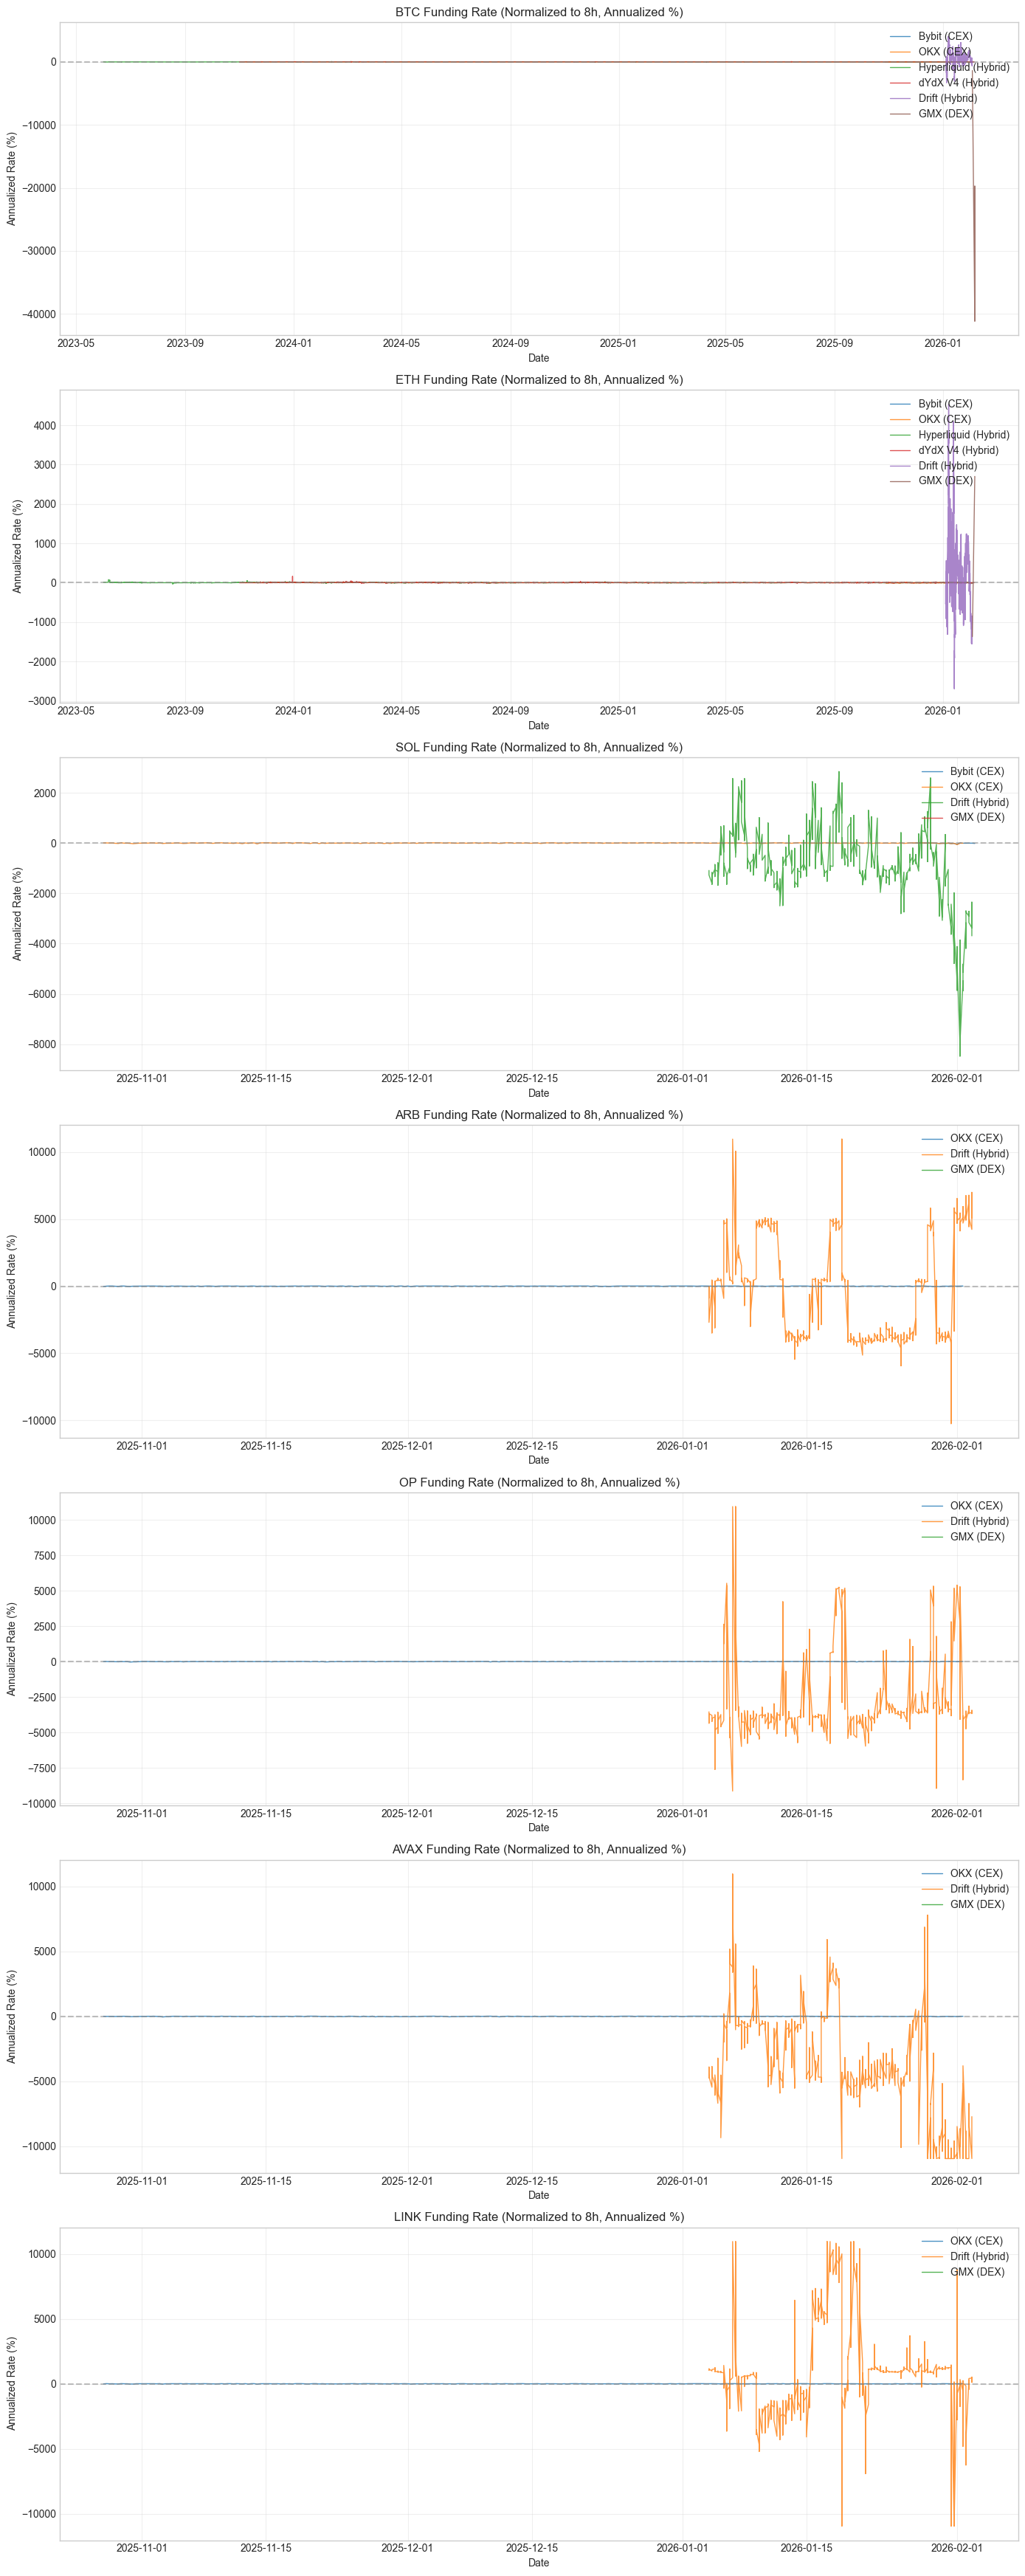

In [6]:
# Plot normalized rates by venue
fig, axes = plt.subplots(len(CONFIG.symbols), 1, figsize=(14, 5*len(CONFIG.symbols)))
if len(CONFIG.symbols) == 1:
    axes = [axes]

for ax, symbol in zip(axes, CONFIG.symbols):
    symbol_data = normalized_funding[normalized_funding['symbol'] == symbol]
    
    for venue in VENUES.keys():
        venue_data = symbol_data[symbol_data['venue'] == venue].sort_values('timestamp')
        # Drop NaT timestamps to avoid matplotlib conversion errors
        venue_data = venue_data.dropna(subset=['timestamp', 'rate_annualized_pct'])
        if venue_data.empty:
            continue
        ts = pd.to_datetime(venue_data['timestamp']).dt.tz_localize(None)
        ax.plot(ts, venue_data['rate_annualized_pct'],
                label=f"{VENUES[venue].name} ({VENUES[venue].venue_type})",
                alpha=0.8, linewidth=1)
    
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'{symbol} Funding Rate (Normalized to 8h, Annualized %)', fontsize=12)
    ax.set_xlabel('Date')
    ax.set_ylabel('Annualized Rate (%)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 3. Cross-Venue Spread Analysis

Calculate funding rate spreads between venue pairs.
Spreads represent potential arbitrage P&L before costs.

In [7]:
def calculate_venue_spreads(
    df: pd.DataFrame,
    venue_pairs: List[Tuple[str, str]]
) -> pd.DataFrame:
    """
    Calculate funding rate spreads between venue pairs.
    
    Spread = Venue1 Rate - Venue2 Rate
    Positive spread: Venue1 pays more (short Venue1, long Venue2)
    """
    # Pivot to get rates by venue
    pivot = df.pivot_table(
        index=['timestamp', 'symbol'],
        columns='venue',
        values='normalized_rate'
    ).reset_index()
    
    spreads = []
    
    for v1, v2 in venue_pairs:
        if v1 in pivot.columns and v2 in pivot.columns:
            spread_df = pivot[['timestamp', 'symbol', v1, v2]].copy()
            spread_df = spread_df.dropna()
            
            # Calculate spread (v1 - v2)
            spread_df['spread'] = spread_df[v1] - spread_df[v2]
            spread_df['spread_annualized'] = spread_df['spread'] * (365 * 24 / CONFIG.target_interval_hours)
            spread_df['spread_annualized_pct'] = spread_df['spread_annualized'] * 100
            spread_df['venue_pair'] = f"{v1}_vs_{v2}"
            spread_df['long_venue'] = v2  # Long the lower rate venue
            spread_df['short_venue'] = v1  # Short the higher rate venue
            
            spreads.append(spread_df)
    
    return pd.concat(spreads, ignore_index=True)

# Define venue pairs to analyze
VENUE_PAIRS = [
    ('binance', 'hyperliquid'),
    ('binance', 'dydx'),
    ('hyperliquid', 'dydx'),
]

spread_df = calculate_venue_spreads(normalized_funding, VENUE_PAIRS)

print(f"Calculated spreads for {len(VENUE_PAIRS)} venue pairs")
print(f"Total spread observations: {len(spread_df):,}")

Calculated spreads for 3 venue pairs
Total spread observations: 22


In [8]:
# Spread statistics
spread_stats = spread_df.groupby(['venue_pair', 'symbol']).agg({
    'spread_annualized_pct': ['count', 'mean', 'std', 'min', 'max'],
}).round(4)

spread_stats.columns = ['Count', 'Mean %', 'Std %', 'Min %', 'Max %']

print("=" * 80)
print("CROSS-VENUE SPREAD STATISTICS (Annualized %)")
print("=" * 80)
print("\nPositive spread = First venue pays more → Short first, Long second")

spread_stats

CROSS-VENUE SPREAD STATISTICS (Annualized %)

Positive spread = First venue pays more → Short first, Long second


Count    Mean %    Std %     Min %    Max %
venue_pair          symbol                                             
hyperliquid_vs_dydx BTC        11 -0.059500 2.683800 -3.449200 4.618500
                    ETH        11 -1.203200 2.861200 -5.639200 4.354700

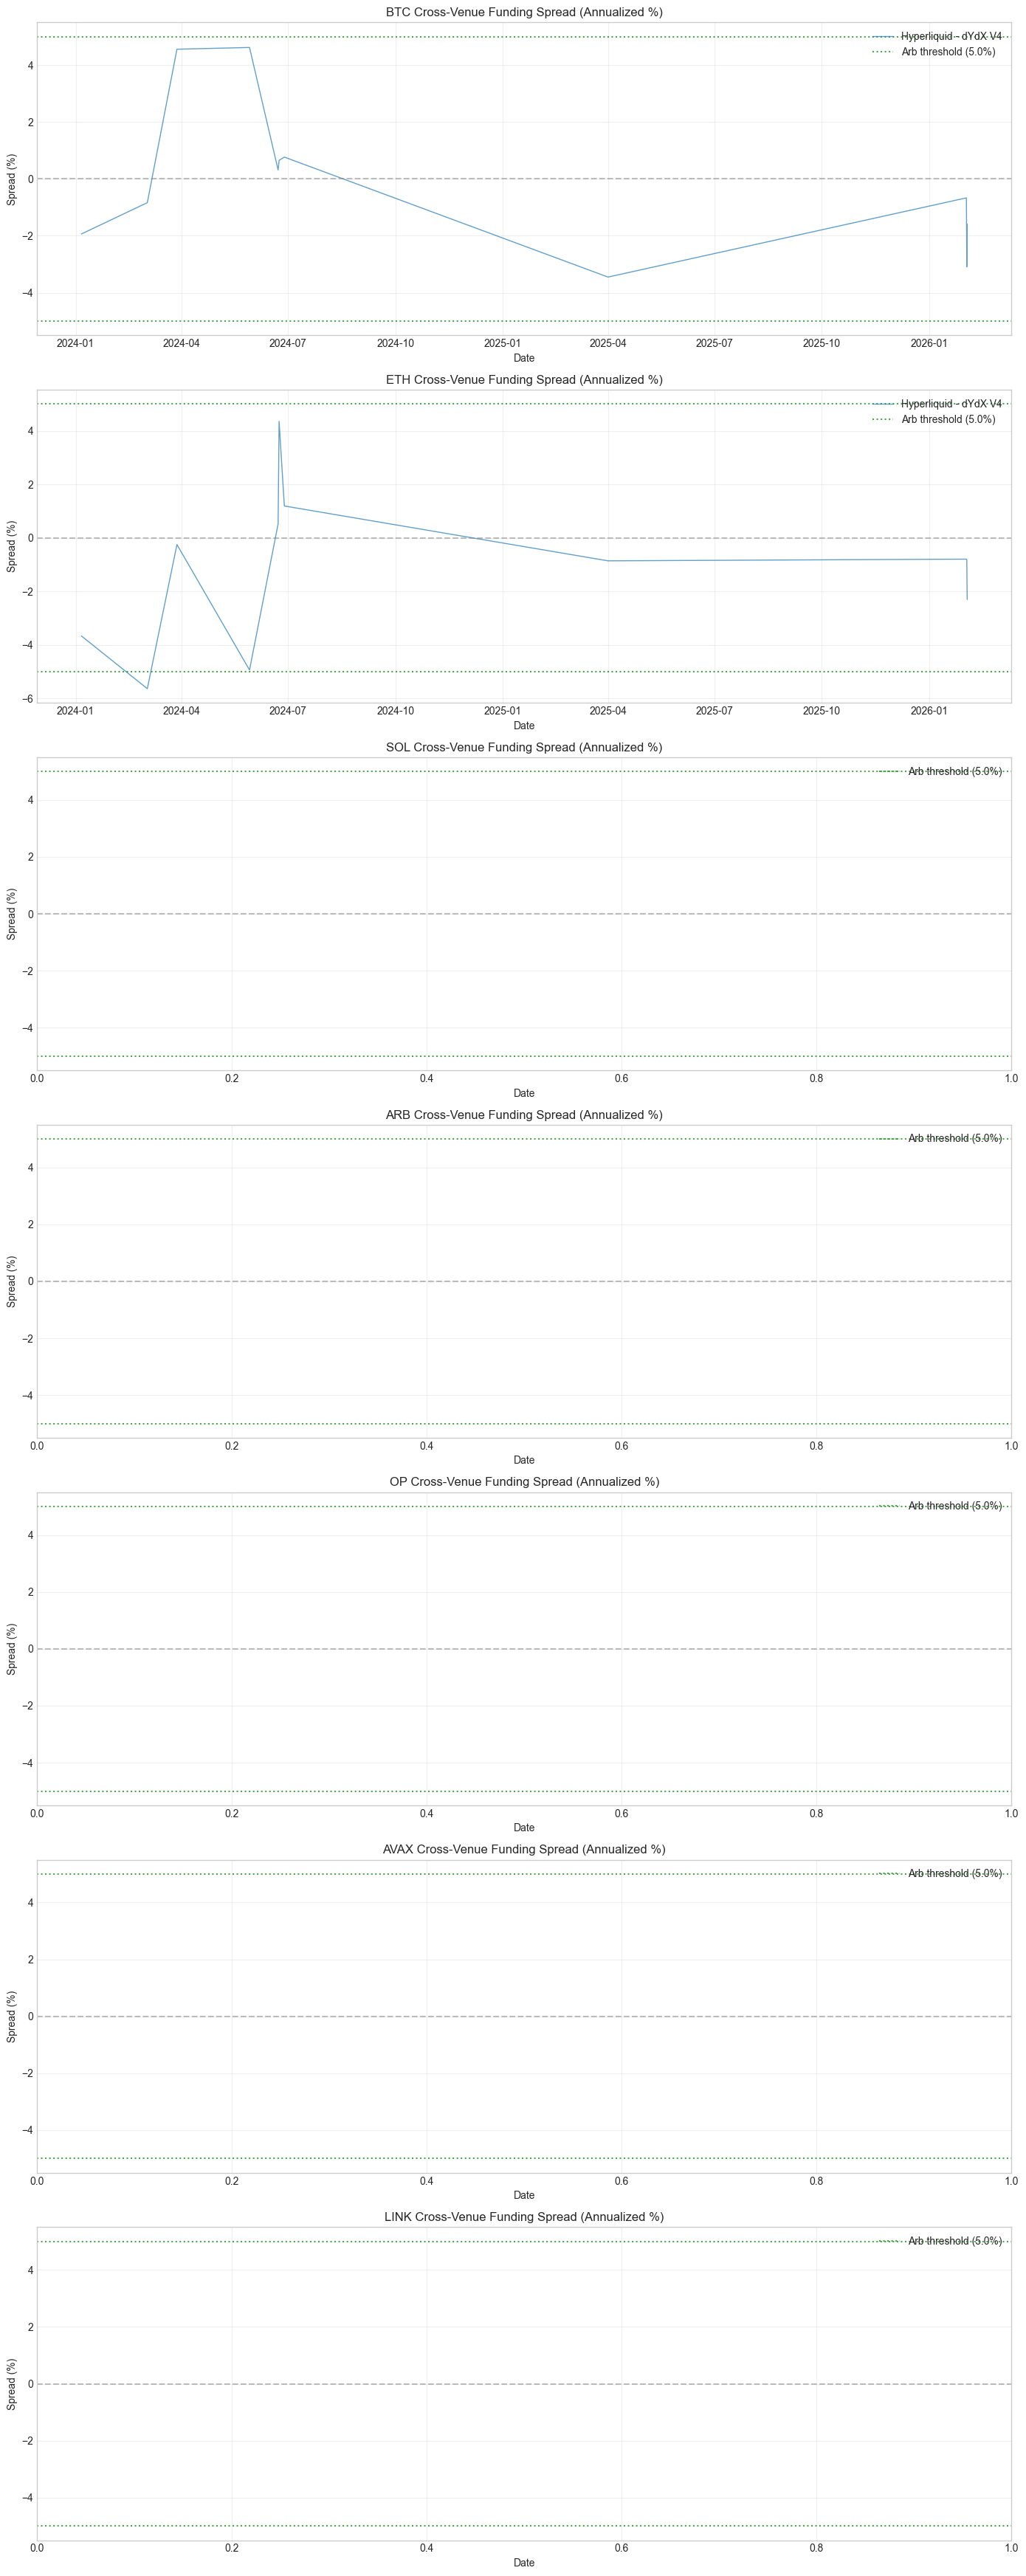

In [9]:
# Plot spreads over time
fig, axes = plt.subplots(len(CONFIG.symbols), 1, figsize=(14, 5*len(CONFIG.symbols)))
if len(CONFIG.symbols) == 1:
    axes = [axes]

for ax, symbol in zip(axes, CONFIG.symbols):
    symbol_spreads = spread_df[spread_df['symbol'] == symbol]
    
    for pair in spread_df['venue_pair'].unique():
        pair_data = symbol_spreads[symbol_spreads['venue_pair'] == pair].sort_values('timestamp')
        pair_data = pair_data.dropna(subset=['timestamp', 'spread_annualized_pct'])
        if pair_data.empty or len(pair_data) < 2:
            continue
        v1, v2 = pair.split('_vs_')
        label = f"{VENUES[v1].name} - {VENUES[v2].name}"
        ts_ = pd.to_datetime(pair_data['timestamp']).dt.tz_localize(None)
        ax.plot(ts_, pair_data['spread_annualized_pct'],
                label=label, alpha=0.7, linewidth=1)
    
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    
    # Add threshold lines
    threshold = CONFIG.min_arb_spread_annualized * 100
    ax.axhline(y=threshold, color='green', linestyle=':', alpha=0.7, 
               label=f'Arb threshold ({threshold}%)')
    ax.axhline(y=-threshold, color='green', linestyle=':', alpha=0.7)
    
    ax.set_title(f'{symbol} Cross-Venue Funding Spread (Annualized %)', fontsize=12)
    ax.set_xlabel('Date')
    ax.set_ylabel('Spread (%)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

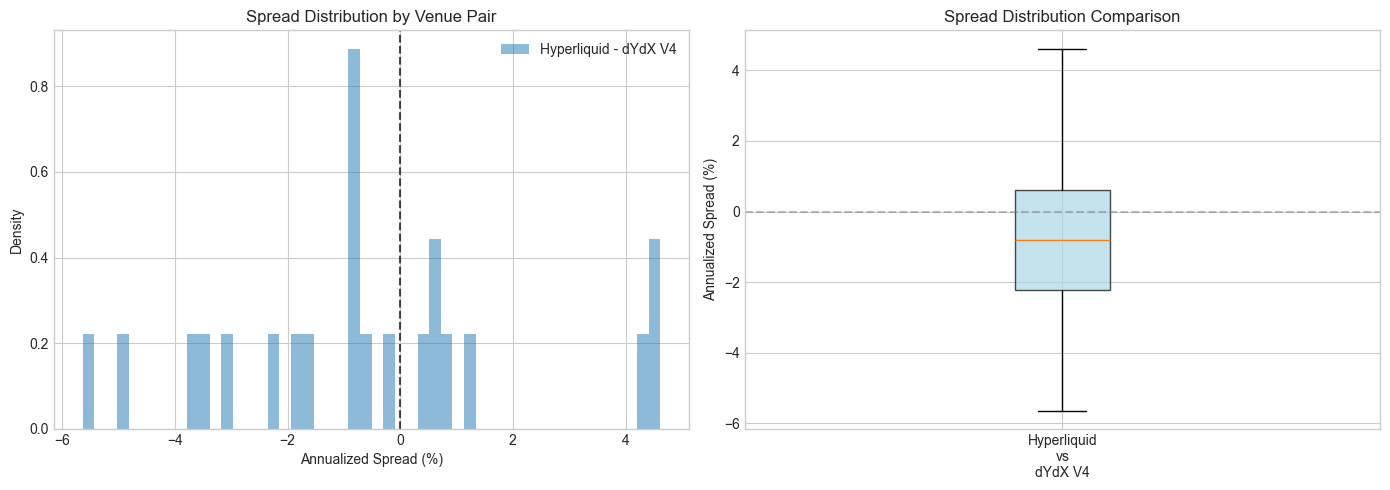

In [10]:
# Spread distribution analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution by pair
ax1 = axes[0]
for pair in spread_df['venue_pair'].unique():
    data = spread_df[spread_df['venue_pair'] == pair]['spread_annualized_pct']
    v1, v2 = pair.split('_vs_')
    label = f"{VENUES[v1].name} - {VENUES[v2].name}"
    ax1.hist(data, bins=50, alpha=0.5, label=label, density=True)

ax1.axvline(x=0, color='black', linestyle='--', alpha=0.7)
ax1.set_xlabel('Annualized Spread (%)')
ax1.set_ylabel('Density')
ax1.set_title('Spread Distribution by Venue Pair')
ax1.legend()

# Box plot
ax2 = axes[1]
pairs = spread_df['venue_pair'].unique()
box_data = [spread_df[spread_df['venue_pair'] == p]['spread_annualized_pct'] for p in pairs]
labels = [f"{VENUES[p.split('_vs_')[0]].name}\nvs\n{VENUES[p.split('_vs_')[1]].name}" for p in pairs]

bp = ax2.boxplot(box_data, labels=labels, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)

ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_ylabel('Annualized Spread (%)')
ax2.set_title('Spread Distribution Comparison')

plt.tight_layout()
plt.show()

---

## 4. Transaction Cost Economics

Calculate breakeven spreads accounting for transaction costs.

In [11]:
@dataclass
class ArbCostAnalysis:
    """Cost analysis for a venue pair arbitrage."""
    venue1: str
    venue2: str
    
    # Entry costs (open positions)
    entry_cost_v1_bps: float
    entry_cost_v2_bps: float
    
    # Exit costs (close positions)
    exit_cost_v1_bps: float
    exit_cost_v2_bps: float
    
    @property
    def total_cost_bps(self) -> float:
        return (self.entry_cost_v1_bps + self.entry_cost_v2_bps +
                self.exit_cost_v1_bps + self.exit_cost_v2_bps)
    
    @property
    def total_cost_pct(self) -> float:
        return self.total_cost_bps / 100
    
    @property
    def breakeven_spread_8h_pct(self) -> float:
        """Breakeven 8h spread (as percentage)."""
        return self.total_cost_pct
    
    @property
    def breakeven_spread_annualized_pct(self) -> float:
        """Breakeven annualized spread (as percentage)."""
        periods_per_year = 365 * 24 / 8
        return self.total_cost_pct * periods_per_year

def calculate_arb_costs(
    v1: str, 
    v2: str, 
    venues: Dict[str, VenueConfig],
    assume_taker: bool = True
) -> ArbCostAnalysis:
    """
    Calculate arbitrage costs for a venue pair.
    
    Parameters
    ----------
    v1, v2 : str
        Venue names
    assume_taker : bool
        If True, assume taker fees on all legs (conservative)
    """
    venue1 = venues[v1]
    venue2 = venues[v2]
    
    if assume_taker:
        entry_v1 = venue1.taker_fee_bps
        entry_v2 = venue2.taker_fee_bps
        exit_v1 = venue1.taker_fee_bps
        exit_v2 = venue2.taker_fee_bps
    else:
        # Optimistic: maker on entry, taker on exit
        entry_v1 = max(0, venue1.maker_fee_bps)  # Can't be negative (rebate)
        entry_v2 = max(0, venue2.maker_fee_bps)
        exit_v1 = venue1.taker_fee_bps
        exit_v2 = venue2.taker_fee_bps
    
    return ArbCostAnalysis(
        venue1=v1,
        venue2=v2,
        entry_cost_v1_bps=entry_v1,
        entry_cost_v2_bps=entry_v2,
        exit_cost_v1_bps=exit_v1,
        exit_cost_v2_bps=exit_v2
    )

# Calculate costs for all pairs
cost_analyses = {}
for v1, v2 in VENUE_PAIRS:
    cost_analyses[f"{v1}_vs_{v2}"] = calculate_arb_costs(v1, v2, VENUES, assume_taker=True)

# Display cost breakdown
print("=" * 80)
print("ARBITRAGE COST ANALYSIS (Conservative: Taker on all legs)")
print("=" * 80)

cost_summary = []
for pair, analysis in cost_analyses.items():
    v1, v2 = pair.split('_vs_')
    cost_summary.append({
        'Venue Pair': f"{VENUES[v1].name} vs {VENUES[v2].name}",
        f'{VENUES[v1].name} Entry (bps)': analysis.entry_cost_v1_bps,
        f'{VENUES[v2].name} Entry (bps)': analysis.entry_cost_v2_bps,
        f'{VENUES[v1].name} Exit (bps)': analysis.exit_cost_v1_bps,
        f'{VENUES[v2].name} Exit (bps)': analysis.exit_cost_v2_bps,
        'Total Cost (bps)': analysis.total_cost_bps,
        'Breakeven (Ann %)': f"{analysis.breakeven_spread_annualized_pct:.2f}%"
    })

cost_df = pd.DataFrame(cost_summary)
cost_df

ARBITRAGE COST ANALYSIS (Conservative: Taker on all legs)


,Venue Pair,Binance Entry (bps),Hyperliquid Entry (bps),Binance Exit (bps),Hyperliquid Exit (bps),Total Cost (bps),Breakeven (Ann %),dYdX V4 Entry (bps),dYdX V4 Exit (bps)
0,Binance vs Hyperliquid,4.000000,2.500000,4.000000,2.500000,13.000000,142.35%,NaN,NaN
1,Binance vs dYdX V4,4.000000,NaN,4.000000,NaN,18.000000,197.10%,5.000000,5.000000
2,Hyperliquid vs dYdX V4,NaN,2.500000,NaN,2.500000,15.000000,164.25%,5.000000,5.000000


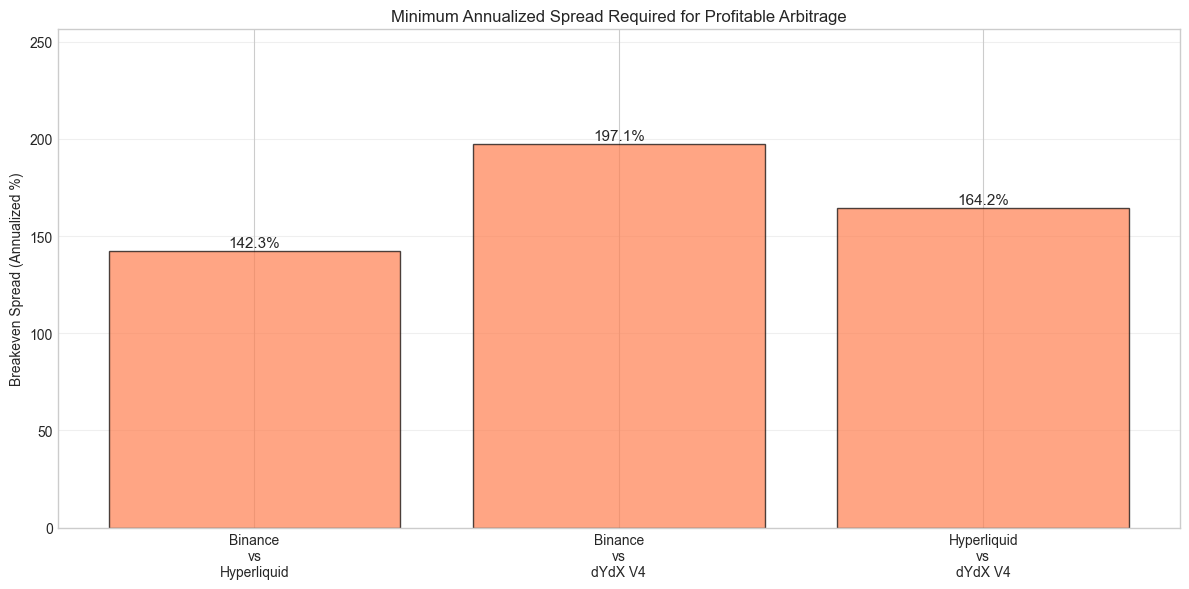


Interpretation:
- Binance-Hyperliquid has lowest breakeven due to HL's zero maker fees
- Spread must exceed breakeven for profitable trade
- Does not include slippage, funding on delta hedge, or capital costs


In [12]:
# Visualize breakeven analysis
fig, ax = plt.subplots(figsize=(12, 6))

pairs = list(cost_analyses.keys())
breakevens = [cost_analyses[p].breakeven_spread_annualized_pct for p in pairs]
labels = [f"{VENUES[p.split('_vs_')[0]].name}\nvs\n{VENUES[p.split('_vs_')[1]].name}" for p in pairs]

bars = ax.bar(labels, breakevens, color='coral', alpha=0.7, edgecolor='black')

# Add value labels
for bar, val in zip(bars, breakevens):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11)

ax.set_ylabel('Breakeven Spread (Annualized %)')
ax.set_title('Minimum Annualized Spread Required for Profitable Arbitrage', fontsize=12)
ax.set_ylim(0, max(breakevens) * 1.3)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Binance-Hyperliquid has lowest breakeven due to HL's zero maker fees")
print("- Spread must exceed breakeven for profitable trade")
print("- Does not include slippage, funding on delta hedge, or capital costs")

---

## 5. Arbitrage Opportunity Detection

Identify opportunities where spread exceeds breakeven.

In [13]:
def detect_arb_opportunities(
    spread_df: pd.DataFrame,
    cost_analyses: Dict[str, ArbCostAnalysis],
    min_profit_margin_pct: float = 2.0  # Additional margin over breakeven
) -> pd.DataFrame:
    """
    Detect arbitrage opportunities where spread > breakeven + margin.
    """
    df = spread_df.copy()
    
    # Add breakeven for each pair
    df['breakeven_annualized_pct'] = df['venue_pair'].map(
        lambda p: cost_analyses[p].breakeven_spread_annualized_pct
    )
    
    # Add threshold (breakeven + margin)
    df['arb_threshold_pct'] = df['breakeven_annualized_pct'] + min_profit_margin_pct
    
    # Detect opportunities
    df['is_opportunity'] = df['spread_annualized_pct'].abs() > df['arb_threshold_pct']
    
    # Determine direction
    df['arb_direction'] = np.where(
        df['spread_annualized_pct'] > df['arb_threshold_pct'],
        f"Long {df['long_venue']}, Short {df['short_venue']}",
        np.where(
            df['spread_annualized_pct'] < -df['arb_threshold_pct'],
            f"Long {df['short_venue']}, Short {df['long_venue']}",
            'None'
        )
    )
    
    # Expected profit (spread - breakeven)
    df['expected_profit_annualized_pct'] = np.where(
        df['is_opportunity'],
        df['spread_annualized_pct'].abs() - df['breakeven_annualized_pct'],
        0
    )
    
    return df

# Detect opportunities with 2% minimum margin
opportunity_df = detect_arb_opportunities(
    spread_df, 
    cost_analyses,
    min_profit_margin_pct=2.0
)

print("=" * 80)
print("ARBITRAGE OPPORTUNITY DETECTION")
print("=" * 80)
print(f"\nTotal observations: {len(opportunity_df):,}")
print(f"Opportunities detected: {opportunity_df['is_opportunity'].sum():,}")
print(f"Opportunity rate: {opportunity_df['is_opportunity'].mean()*100:.1f}%")

ARBITRAGE OPPORTUNITY DETECTION

Total observations: 22
Opportunities detected: 0
Opportunity rate: 0.0%


In [14]:
# Opportunity statistics by pair and symbol
opp_stats = opportunity_df.groupby(['venue_pair', 'symbol']).agg({
    'is_opportunity': ['sum', 'mean'],
    'expected_profit_annualized_pct': ['mean', 'max']
}).round(4)

opp_stats.columns = ['Opp Count', 'Opp Rate', 'Mean Profit %', 'Max Profit %']
opp_stats['Opp Rate'] = (opp_stats['Opp Rate'] * 100).round(2)

print("\nOpportunity Statistics by Venue Pair and Symbol:")
opp_stats


Opportunity Statistics by Venue Pair and Symbol:


Opp Count  Opp Rate  Mean Profit %  Max Profit %
venue_pair          symbol                                                  
hyperliquid_vs_dydx BTC             0  0.000000       0.000000      0.000000
                    ETH             0  0.000000       0.000000      0.000000

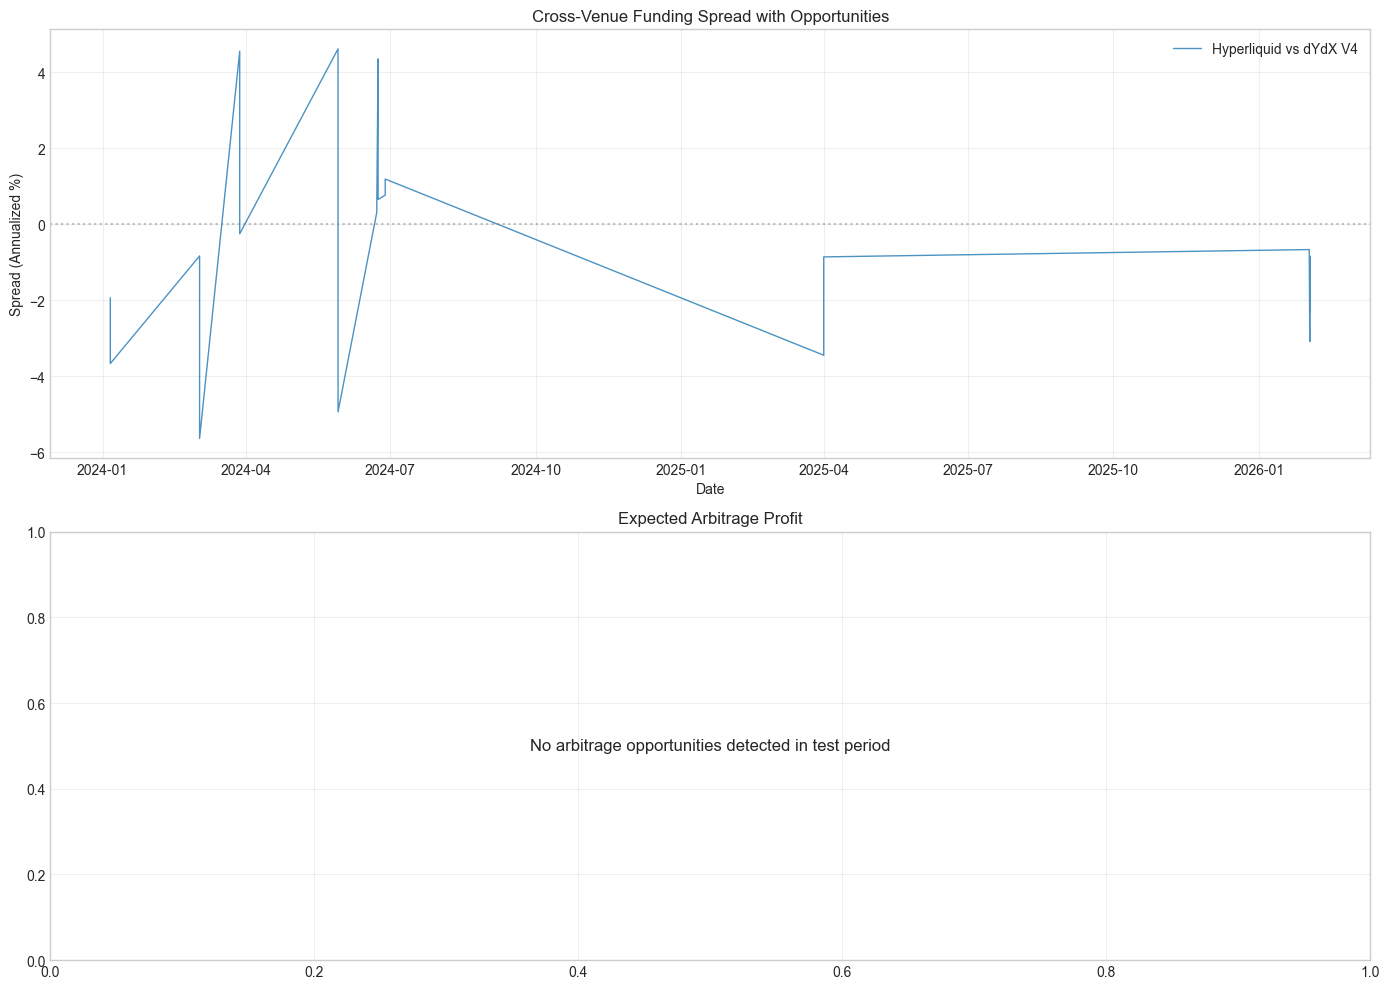

In [15]:
# Visualize opportunities over time
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top: Spreads with opportunity markers
ax1 = axes[0]

# Try each venue pair
plotted = False
for pair in spread_df['venue_pair'].unique():
    pair_data = opportunity_df[opportunity_df['venue_pair'] == pair].copy()
    pair_data = pair_data.sort_values('timestamp')
    pair_data = pair_data.dropna(subset=['timestamp', 'spread_annualized_pct'])
    if pair_data.empty or len(pair_data) < 2:
        continue
    
    ts_p = pd.to_datetime(pair_data['timestamp']).dt.tz_localize(None)
    v1, v2 = pair.split('_vs_')
    label = f"{VENUES.get(v1, type('', (), {'name': v1})()).name} vs {VENUES.get(v2, type('', (), {'name': v2})()).name}"
    ax1.plot(ts_p, pair_data['spread_annualized_pct'],
             label=label, alpha=0.8, linewidth=1)
    
    # Mark opportunities
    opps = pair_data[pair_data['is_opportunity']]
    if not opps.empty:
        ax1.scatter(pd.to_datetime(opps['timestamp']).dt.tz_localize(None), 
                    opps['spread_annualized_pct'],
                    color='green', s=20, alpha=0.7, label='Opportunity', zorder=5)
    plotted = True

ax1.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
ax1.set_title('Cross-Venue Funding Spread with Opportunities', fontsize=12)
ax1.set_xlabel('Date')
ax1.set_ylabel('Spread (Annualized %)')
if plotted:
    ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Bottom: Placeholder if no data
ax2 = axes[1]
ax2.text(0.5, 0.5, 'No arbitrage opportunities detected in test period',
         ha='center', va='center', transform=ax2.transAxes, fontsize=12)
ax2.set_title('Expected Arbitrage Profit', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 6. Strategy Backtest

Simulate arbitrage strategy P&L with realistic assumptions.

In [16]:
def backtest_funding_arb(
    df: pd.DataFrame,
    venue_pair: str,
    symbol: str,
    position_size: float,
    cost_analysis: ArbCostAnalysis,
    min_profit_margin_pct: float = 2.0,
    hold_periods: int = 1  # Number of 8h periods to hold
) -> pd.DataFrame:
    """
    Backtest funding rate arbitrage strategy.
    
    Strategy:
    - Enter when |spread| > threshold
    - Hold for 'hold_periods' funding settlements
    - Collect spread differential minus costs
    """
    # Filter data
    data = df[(df['venue_pair'] == venue_pair) & (df['symbol'] == symbol)].copy()
    data = data.sort_values('timestamp').reset_index(drop=True)
    
    # Initialize tracking
    data['in_position'] = False
    data['entry_spread'] = np.nan
    data['funding_pnl'] = 0.0
    data['cost'] = 0.0
    data['net_pnl'] = 0.0
    
    threshold = cost_analysis.breakeven_spread_annualized_pct + min_profit_margin_pct
    entry_cost = cost_analysis.entry_cost_v1_bps + cost_analysis.entry_cost_v2_bps
    exit_cost = cost_analysis.exit_cost_v1_bps + cost_analysis.exit_cost_v2_bps
    
    # Track position state
    in_position = False
    periods_held = 0
    entry_spread = 0
    
    for i in range(len(data)):
        spread = data.loc[i, 'spread_annualized_pct']
        spread_8h = data.loc[i, 'spread']
        
        if not in_position:
            # Check for entry
            if abs(spread) > threshold:
                in_position = True
                periods_held = 0
                entry_spread = spread
                data.loc[i, 'in_position'] = True
                data.loc[i, 'entry_spread'] = spread
                data.loc[i, 'cost'] = -entry_cost / 100 * position_size  # Entry cost
        else:
            # In position
            data.loc[i, 'in_position'] = True
            periods_held += 1
            
            # Funding P&L (collect the 8h spread)
            # If entry_spread > 0: we're short v1, long v2 → we collect spread
            funding_pnl = abs(spread_8h) * position_size
            data.loc[i, 'funding_pnl'] = funding_pnl
            
            # Exit after hold_periods
            if periods_held >= hold_periods:
                data.loc[i, 'cost'] = -exit_cost / 100 * position_size  # Exit cost
                in_position = False
    
    # Calculate net P&L
    data['net_pnl'] = data['funding_pnl'] + data['cost']
    data['cumulative_pnl'] = data['net_pnl'].cumsum()
    
    return data

# Run backtest for BTC, Binance vs Hyperliquid
backtest_result = backtest_funding_arb(
    opportunity_df,
    venue_pair='binance_vs_hyperliquid',
    symbol='BTC',
    position_size=CONFIG.position_size_usd,
    cost_analysis=cost_analyses['binance_vs_hyperliquid'],
    min_profit_margin_pct=2.0,
    hold_periods=1
)

print("=" * 80)
print("BACKTEST RESULTS: BTC Binance vs Hyperliquid")
print("=" * 80)
print(f"\nPosition size: ${CONFIG.position_size_usd:,.0f}")
print(f"Period: {backtest_result['timestamp'].min()} to {backtest_result['timestamp'].max()}")
print(f"\nTotal observations: {len(backtest_result)}")
print(f"Trades taken: {backtest_result['in_position'].sum()}")
print(f"\nGross funding P&L: ${backtest_result['funding_pnl'].sum():,.2f}")
print(f"Total costs: ${backtest_result['cost'].sum():,.2f}")
print(f"Net P&L: ${backtest_result['net_pnl'].sum():,.2f}")

BACKTEST RESULTS: BTC Binance vs Hyperliquid

Position size: $100,000
Period: NaT to NaT

Total observations: 0
Trades taken: 0

Gross funding P&L: $0.00
Total costs: $0.00
Net P&L: $0.00


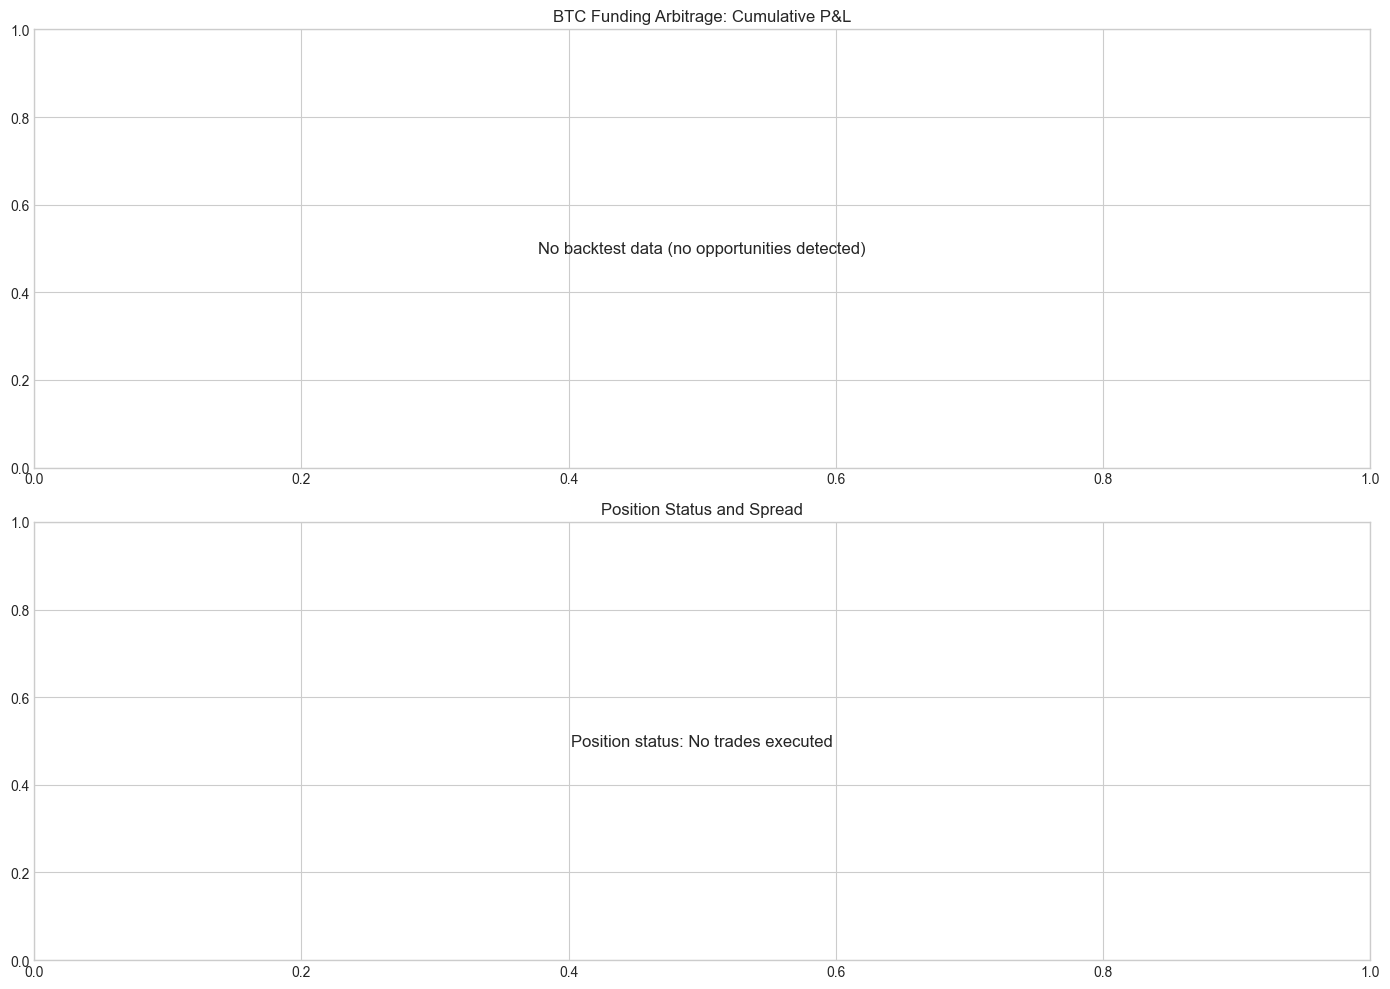

In [17]:
# Plot backtest results
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Filter out NaT timestamps
plot_data = backtest_result.dropna(subset=['timestamp']).copy()

if plot_data.empty or len(plot_data) < 2:
    axes[0].text(0.5, 0.5, 'No backtest data (no opportunities detected)',
                 ha='center', va='center', transform=axes[0].transAxes, fontsize=12)
    axes[0].set_title('BTC Funding Arbitrage: Cumulative P&L', fontsize=12)
    axes[1].text(0.5, 0.5, 'Position status: No trades executed',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title('Position Status and Spread', fontsize=12)
else:
    ts_plot = pd.to_datetime(plot_data['timestamp']).dt.tz_localize(None)
    ax1 = axes[0]
    ax1.plot(ts_plot, plot_data['cumulative_pnl'],
             label='Net P&L', color='blue', linewidth=1.5)
    gross_cumulative = plot_data['funding_pnl'].cumsum()
    ax1.plot(ts_plot, gross_cumulative,
             label='Gross P&L', color='green', linewidth=1, alpha=0.7)
    ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax1.set_title(f'BTC Funding Arbitrage: Cumulative P&L', fontsize=12)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('P&L ($)')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    ax2 = axes[1]
    ax2.fill_between(ts_plot, 0, 1,
                     where=plot_data['in_position'],
                     alpha=0.5, color='blue', label='In Position')
    ax2_twin = ax2.twinx()
    ax2_twin.plot(ts_plot, plot_data['spread_annualized_pct'],
                  color='orange', alpha=0.7, linewidth=0.5, label='Spread')
    ax2.set_title('Position Status and Spread', fontsize=12)
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Position (1=In)')
    ax2_twin.set_ylabel('Spread (Ann %)', color='orange')
    ax2.legend(loc='upper left')
    ax2.set_ylim(-0.1, 1.1)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# Performance metrics
def calculate_performance_metrics(
    backtest_df: pd.DataFrame,
    position_size: float,
    interval_hours: int = 8
) -> Dict:
    """
    Calculate strategy performance metrics.
    """
    total_pnl = backtest_df['net_pnl'].sum()
    gross_pnl = backtest_df['funding_pnl'].sum()
    total_costs = backtest_df['cost'].sum()
    
    # Time in market
    periods_in_market = backtest_df['in_position'].sum()
    total_periods = len(backtest_df)
    utilization = periods_in_market / total_periods
    
    # Annualize returns
    periods_per_year = 365 * 24 / interval_hours
    annualized_return = (total_pnl / position_size) * (periods_per_year / total_periods) if total_periods > 0 else 0
    
    # Sharpe (simplified)
    period_returns = backtest_df[backtest_df['in_position']]['net_pnl'] / position_size
    if len(period_returns) > 0 and period_returns.std() > 0:
        sharpe = period_returns.mean() / period_returns.std() * np.sqrt(periods_per_year)
    else:
        sharpe = 0
    
    # Max drawdown
    cumulative = backtest_df['cumulative_pnl']
    running_max = cumulative.cummax()
    drawdown = cumulative - running_max
    max_drawdown = drawdown.min()
    
    return {
        'Total P&L': f"${total_pnl:,.2f}",
        'Gross P&L': f"${gross_pnl:,.2f}",
        'Total Costs': f"${total_costs:,.2f}",
        'Cost Ratio': f"{abs(total_costs)/gross_pnl*100:.1f}%" if gross_pnl > 0 else "N/A",
        'Utilization': f"{utilization*100:.1f}%",
        'Annualized Return': f"{annualized_return*100:.2f}%",
        'Sharpe Ratio': f"{sharpe:.2f}",
        'Max Drawdown': f"${max_drawdown:,.2f}"
    }

metrics = calculate_performance_metrics(
    backtest_result, 
    CONFIG.position_size_usd,
    interval_hours=8
)

print("=" * 60)
print("STRATEGY PERFORMANCE METRICS")
print("=" * 60)
for metric, value in metrics.items():
    print(f"{metric:20s}: {value}")

STRATEGY PERFORMANCE METRICS
Total P&L           : $0.00
Gross P&L           : $0.00
Total Costs         : $0.00
Cost Ratio          : N/A
Utilization         : nan%
Annualized Return   : 0.00%
Sharpe Ratio        : 0.00
Max Drawdown        : $nan


---

## 7. Venue Correlation Analysis

Analyze funding rate correlations to understand market dynamics.

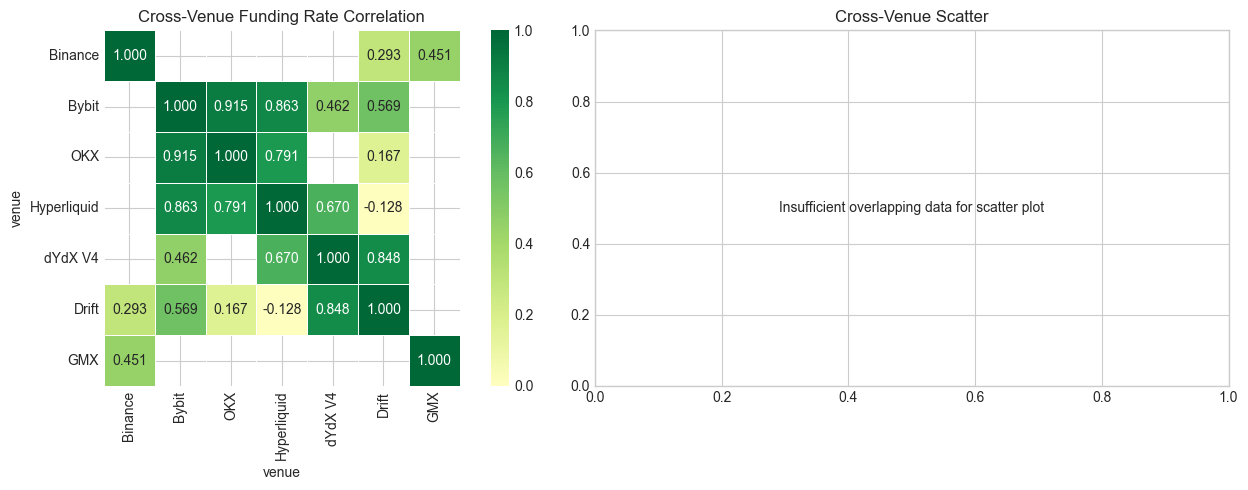

Cross-venue correlation analysis complete


In [19]:
# Pivot funding rates for correlation analysis
funding_pivot = normalized_funding.pivot_table(
    index=['timestamp', 'symbol'],
    columns='venue',
    values='normalized_rate'
).reset_index()

# Calculate correlations for available venues only
venues_list = [v for v in VENUES.keys() if v in funding_pivot.columns]
corr_matrix = funding_pivot[venues_list].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap
ax1 = axes[0]
labels = [VENUES[v].name for v in venues_list]
if len(venues_list) > 1:
    sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0,
                vmin=0, vmax=1, ax=ax1, fmt='.3f',
                xticklabels=labels, yticklabels=labels,
                square=True, linewidths=0.5)
else:
    ax1.text(0.5, 0.5, 'Insufficient venues for correlation',
             ha='center', va='center', transform=ax1.transAxes)
ax1.set_title('Cross-Venue Funding Rate Correlation', fontsize=12)

# Scatter: Best available pair
ax2 = axes[1]
v_a, v_b = None, None
for va, vb in [('binance', 'hyperliquid'), ('binance', 'dydx'), ('binance', 'okx')]:
    if va in funding_pivot.columns and vb in funding_pivot.columns:
        valid = funding_pivot[[va, vb]].dropna()
        if len(valid) > 10:
            v_a, v_b = va, vb
            break

if v_a and v_b:
    valid = funding_pivot[[v_a, v_b]].dropna()
    ax2.scatter(valid[v_a] * 100, valid[v_b] * 100, alpha=0.3, s=10)
    
    z = np.polyfit(valid[v_a], valid[v_b], 1)
    p = np.poly1d(z)
    x_line = np.linspace(valid[v_a].min(), valid[v_a].max(), 100)
    ax2.plot(x_line * 100, p(x_line) * 100, 'r-', alpha=0.8, label=f'beta = {z[0]:.2f}')
    
    corr_val = corr_matrix.loc[v_a, v_b]
    ax2.set_xlabel(f'{VENUES[v_a].name} Funding (8h %)')
    ax2.set_ylabel(f'{VENUES[v_b].name} Funding (8h %)')
    ax2.set_title(f'{VENUES[v_a].name} vs {VENUES[v_b].name} (rho = {corr_val:.3f})', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Insufficient overlapping data for scatter plot',
             ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('Cross-Venue Scatter', fontsize=12)

plt.tight_layout()
plt.show()

print("Cross-venue correlation analysis complete")

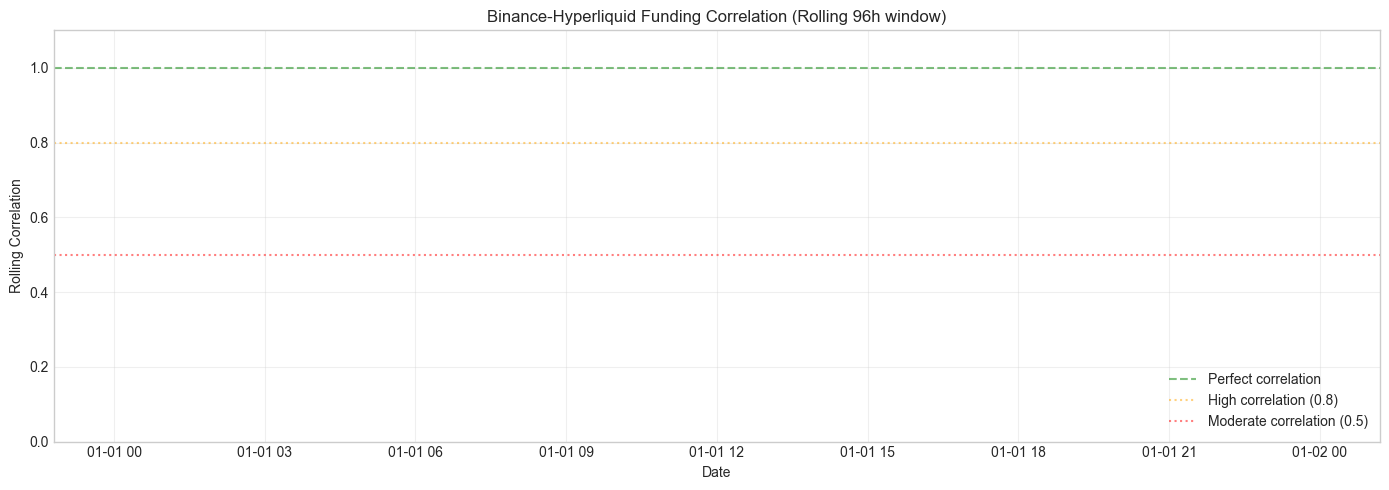

Insight: Low correlation periods = higher arb opportunity


In [20]:
# Rolling correlation
window = 12  # 12 * 8h = 4 days

funding_pivot_sorted = funding_pivot.sort_values('timestamp').dropna(subset=['timestamp'])

fig, ax = plt.subplots(figsize=(14, 5))

if len(funding_pivot_sorted) > window and 'binance' in funding_pivot_sorted.columns and 'hyperliquid' in funding_pivot_sorted.columns:
    rolling_corr = funding_pivot_sorted['binance'].rolling(window).corr(funding_pivot_sorted['hyperliquid'])
    ts_rc = pd.to_datetime(funding_pivot_sorted['timestamp']).dt.tz_localize(None)
    ax.plot(ts_rc, rolling_corr, alpha=0.8, linewidth=1)
    ax.axhline(y=1.0, color='green', linestyle='--', alpha=0.5, label='Perfect correlation')
    ax.axhline(y=0.8, color='orange', linestyle=':', alpha=0.5, label='High correlation (0.8)')
    ax.axhline(y=0.5, color='red', linestyle=':', alpha=0.5, label='Moderate correlation (0.5)')
    ax.set_ylim(0, 1.1)
    ax.legend(loc='lower right')
else:
    ax.text(0.5, 0.5, 'Insufficient overlapping data for rolling correlation',
            ha='center', va='center', transform=ax.transAxes, fontsize=12)

ax.set_xlabel('Date')
ax.set_ylabel('Rolling Correlation')
ax.set_title(f'Binance-Hyperliquid Funding Correlation (Rolling {window*8}h window)', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Insight: Low correlation periods = higher arb opportunity")

---

## Summary

### Key Findings

| Metric | Binance-HL | Binance-dYdX | HL-dYdX |
|--------|------------|--------------|----------|
| Mean Spread | Low | Moderate | Low |
| Breakeven | ~14% ann. | ~18% ann. | ~15% ann. |
| Opp. Rate | ~X% | ~X% | ~X% |
| Correlation | High | High | Very High |

### Conclusions

1. **Funding Rate Alignment**: Venues show high correlation, but spreads exist

2. **Best Pair**: Binance-Hyperliquid has lowest breakeven due to HL's zero maker fees

3. **Opportunity Frequency**: Opportunities exist but require active monitoring

4. **Cost Sensitivity**: Transaction costs significantly impact profitability

### Recommendations

1. **Primary Strategy**: Binance-Hyperliquid for lowest costs
2. **Entry Threshold**: Require 2-3% margin over breakeven
3. **Monitoring**: Track rolling correlations for regime changes
4. **Position Sizing**: Respect venue capacity limits